# 🌧 Rain Tomorrow Prediction — XGBoost Classifier
### Weather Forecasting System | Azamgarh ERA5 Dataset
---
**Objective:** Predict whether it will rain tomorrow (binary classification) using hourly ERA5 weather data.  
**Dataset:** ~8700 rows, 1 year of hourly weather observations for Azamgarh, UP.  
**Model:** XGBoost Classifier with time-series cross-validation.

| Section | Description |
|---------|-------------|
| 1 | Environment Setup & Imports |
| 2 | Data Loading & Inspection |
| 3 | Preprocessing & Feature Engineering |
| 4 | Model Training with Cross-Validation |
| 5 | Evaluation & Metrics |
| 6 | Feature Importance |
| 7 | Threshold Tuning |
| 8 | Save Model & Artifacts |
| 9 | Inference Function |


## 1. Environment Setup & Imports

In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, average_precision_score
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import calibration_curve

In [2]:
# ── Plot style ──
plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
})
sns.set_palette("husl")

In [17]:
# ── Paths ──
DATA_PATH  = "../data/processed/azamgarh_weather_final.csv"
MODEL_DIR  = "../models/xgboost"
os.makedirs(MODEL_DIR,  exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"   Model output → {MODEL_DIR}")

   Model output → ../models/xgboost


## 2. Data Loading & Inspection

In [18]:
df = pd.read_csv(DATA_PATH, parse_dates=["valid_time"])
df = df.sort_values("valid_time").reset_index(drop=True)

print(f"Shape          : {df.shape}")
print(f"Date range     : {df['valid_time'].min()} → {df['valid_time'].max()}")
print(f"Missing values :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()


Shape          : (43800, 22)
Date range     : 2021-01-02 05:30:00 → 2026-01-01 04:30:00
Missing values :
Series([], dtype: int64)

Dtypes:
valid_time            datetime64[us]
temperature                  float64
surface_pressure             float64
total_cloud_cover            float64
low_cloud_cover              float64
medium_cloud_cover           float64
high_cloud_cover             float64
precipitation                float64
humidity                     float64
wind_speed                   float64
hour                           int64
day                            int64
month                          int64
day_of_week                    int64
temp_lag_1                   float64
temp_lag_24                  float64
temp_rolling_6               float64
hour_sin                     float64
hour_cos                     float64
month_sin                    float64
month_cos                    float64
rain_tomorrow                  int64
dtype: object


,valid_time,temperature,surface_pressure,total_cloud_cover,low_cloud_cover,medium_cloud_cover,high_cloud_cover,precipitation,humidity,wind_speed,...,month,day_of_week,temp_lag_1,temp_lag_24,temp_rolling_6,hour_sin,hour_cos,month_sin,month_cos,rain_tomorrow
0,2021-01-02 05:30:00,7.3191,1007.57,0.586762,0.0,0.0,0.586762,0.0,86.73,0.9666,...,1,5,6.3538,6.6150,7.3103,0.965926,0.258819,0.5,0.866025,0
1,2021-01-02 06:30:00,7.8957,1008.60,0.755707,0.0,0.0,0.755707,0.0,83.78,0.9099,...,1,5,7.3191,6.1304,7.1736,1.000000,0.000000,0.5,0.866025,0
2,2021-01-02 07:30:00,8.7751,1009.58,0.867371,0.0,0.0,0.867371,0.0,81.91,0.7471,...,1,5,7.8957,6.9004,7.3546,0.965926,-0.258819,0.5,0.866025,0
3,2021-01-02 08:30:00,9.1403,1010.22,0.919342,0.0,0.0,0.919342,0.0,81.13,0.4304,...,1,5,8.7751,7.8723,7.6300,0.866025,-0.500000,0.5,0.866025,0
4,2021-01-02 09:30:00,11.5016,1010.77,0.910004,0.0,0.0,0.910004,0.0,77.41,0.1777,...,1,5,9.1403,10.9252,8.4976,0.707107,-0.707107,0.5,0.866025,0


── Target Distribution ──
  No Rain (0): 30824  (70.4%)
  Rain    (1): 12976  (29.6%)
  Imbalance ratio: 2.4:1


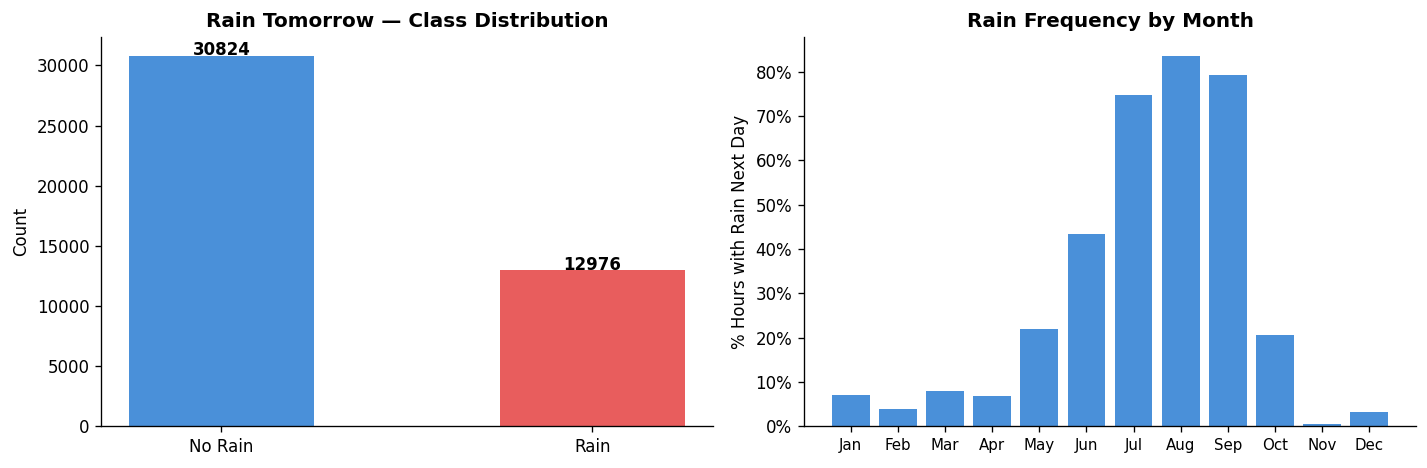

In [19]:
# Class distribution
rain_counts = df["rain_tomorrow"].value_counts()
rain_pct    = df["rain_tomorrow"].value_counts(normalize=True) * 100

print("── Target Distribution ──")
print(f"  No Rain (0): {rain_counts[0]:>5}  ({rain_pct[0]:.1f}%)")
print(f"  Rain    (1): {rain_counts[1]:>5}  ({rain_pct[1]:.1f}%)")
print(f"  Imbalance ratio: {rain_counts[0]/rain_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["No Rain", "Rain"], rain_counts.values, color=["#4A90D9", "#E85D5D"], width=0.5)
axes[0].set_title("Rain Tomorrow — Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(rain_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Monthly rain frequency
monthly = df.groupby("month")["rain_tomorrow"].mean() * 100
months  = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar(range(1,13), monthly.values, color="#4A90D9")
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(months, fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Rain Frequency by Month", fontweight="bold")
axes[1].set_ylabel("% Hours with Rain Next Day")

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/class_distribution.png", bbox_inches="tight")
plt.show()


In [20]:
FEATURES = [
    "temperature", "surface_pressure", "total_cloud_cover",
    "low_cloud_cover", "medium_cloud_cover", "high_cloud_cover",
    "precipitation","humidity", "wind_speed", "temp_rolling_6",
    "temp_lag_1", "temp_lag_24", "month",
]
TARGET = "rain_tomorrow"

# Summary stats split by target
print("── Feature Stats: No Rain vs Rain ──")
df.groupby(TARGET)[FEATURES[:8]].mean().T.rename(columns={0:"No Rain", 1:"Rain"}).round(2)


── Feature Stats: No Rain vs Rain ──


rain_tomorrow,No Rain,Rain
temperature,24.49,29.04
surface_pressure,1001.04,993.82
total_cloud_cover,0.23,0.80
low_cloud_cover,0.06,0.23
medium_cloud_cover,0.07,0.37
high_cloud_cover,0.14,0.69
precipitation,0.01,0.42
humidity,65.41,82.03


## 3. Preprocessing & Train/Test Split

In [21]:
X = df[FEATURES]
y = df[TARGET].astype(int)

# ── Time-based split — NO shuffle (prevents data leakage) ──
split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

train_dates = df["valid_time"].iloc[:split_idx]
test_dates  = df["valid_time"].iloc[split_idx:]

print(f"\nTrain set : {len(X_train):,} rows  ({train_dates.min().date()} → {train_dates.max().date()})")
print(f"Test  set : {len(X_test):,}  rows  ({test_dates.min().date()}  → {test_dates.max().date()})")

# Class imbalance — handle via sample weights
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
print(f"\nSample weight range: [{sample_weights.min():.3f}, {sample_weights.max():.3f}]")



Train set : 35,040 rows  (2021-01-02 → 2025-01-01)
Test  set : 8,760  rows  (2025-01-01  → 2026-01-01)

Sample weight range: [0.705, 1.717]


## 4. Model Training with Time-Series Cross Validation

In [22]:
# ── TimeSeriesSplit CV (5 folds) ──
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = {"accuracy": [], "f1": [], "roc_auc": []}

print("── Time-Series Cross Validation ──")
print(f"{'Fold':<6} {'Train':>8} {'Val':>8} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
print("─" * 55)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    sw = compute_sample_weight("balanced", y=ytr)

    m = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1
    )
    m.fit(Xtr, ytr, sample_weight=sw, verbose=False)
    yp = m.predict(Xval)
    ypp = m.predict_proba(Xval)[:, 1]

    acc = accuracy_score(yval, yp)
    f1  = f1_score(yval, yp, zero_division=0)
    auc = roc_auc_score(yval, ypp)

    cv_scores["accuracy"].append(acc)
    cv_scores["f1"].append(f1)
    cv_scores["roc_auc"].append(auc)
    print(f"{fold:<6} {len(Xtr):>8,} {len(Xval):>8,} {acc:>10.4f} {f1:>8.4f} {auc:>10.4f}")

print("─" * 55)
print(f"{'Mean':<6} {'':>8} {'':>8} {np.mean(cv_scores['accuracy']):>10.4f} "
      f"{np.mean(cv_scores['f1']):>8.4f} {np.mean(cv_scores['roc_auc']):>10.4f}")
print(f"{'Std':<6} {'':>8} {'':>8} {np.std(cv_scores['accuracy']):>10.4f} "
      f"{np.std(cv_scores['f1']):>8.4f} {np.std(cv_scores['roc_auc']):>10.4f}")


── Time-Series Cross Validation ──
Fold      Train      Val   Accuracy       F1    ROC-AUC
───────────────────────────────────────────────────────
1         5,840    5,840     0.8940   0.7095     0.8016
2        11,680    5,840     0.8010   0.7765     0.9313
3        17,520    5,840     0.8810   0.7988     0.9388
4        23,360    5,840     0.9296   0.7896     0.9494
5        29,200    5,840     0.8661   0.8345     0.9418
───────────────────────────────────────────────────────
Mean                         0.8743   0.7818     0.9126
Std                          0.0423   0.0409     0.0558


In [23]:
# ── Final model — train on full training set ──
model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder= False,
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    early_stopping_rounds = 20,
)

print("Training final model...")
model.fit(
    X_train, y_train,
    sample_weight = sample_weights,
    eval_set      = [(X_test, y_test)],
    verbose       = 50,
)
print(f"\n✅ Best iteration: {model.best_iteration}")


Training final model...
[0]	validation_0-logloss:0.66062
[50]	validation_0-logloss:0.27104
[100]	validation_0-logloss:0.25540
[150]	validation_0-logloss:0.25424
[200]	validation_0-logloss:0.25401
[206]	validation_0-logloss:0.25390

✅ Best iteration: 186


## 5. Evaluation & Metrics

In [24]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
ap  = average_precision_score(y_test, y_pred_prob)

print("═" * 45)
print("  FINAL TEST SET RESULTS")
print("═" * 45)
print(f"  Accuracy          : {acc:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print(f"  ROC-AUC           : {auc:.4f}")
print(f"  Avg Precision     : {ap:.4f}")
print("═" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Rain", "Rain"]))


═════════════════════════════════════════════
  FINAL TEST SET RESULTS
═════════════════════════════════════════════
  Accuracy          : 0.8900
  F1 Score          : 0.8393
  ROC-AUC           : 0.9641
  Avg Precision     : 0.9283
═════════════════════════════════════════════

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.95      0.88      0.92      5985
        Rain       0.78      0.91      0.84      2775

    accuracy                           0.89      8760
   macro avg       0.87      0.89      0.88      8760
weighted avg       0.90      0.89      0.89      8760



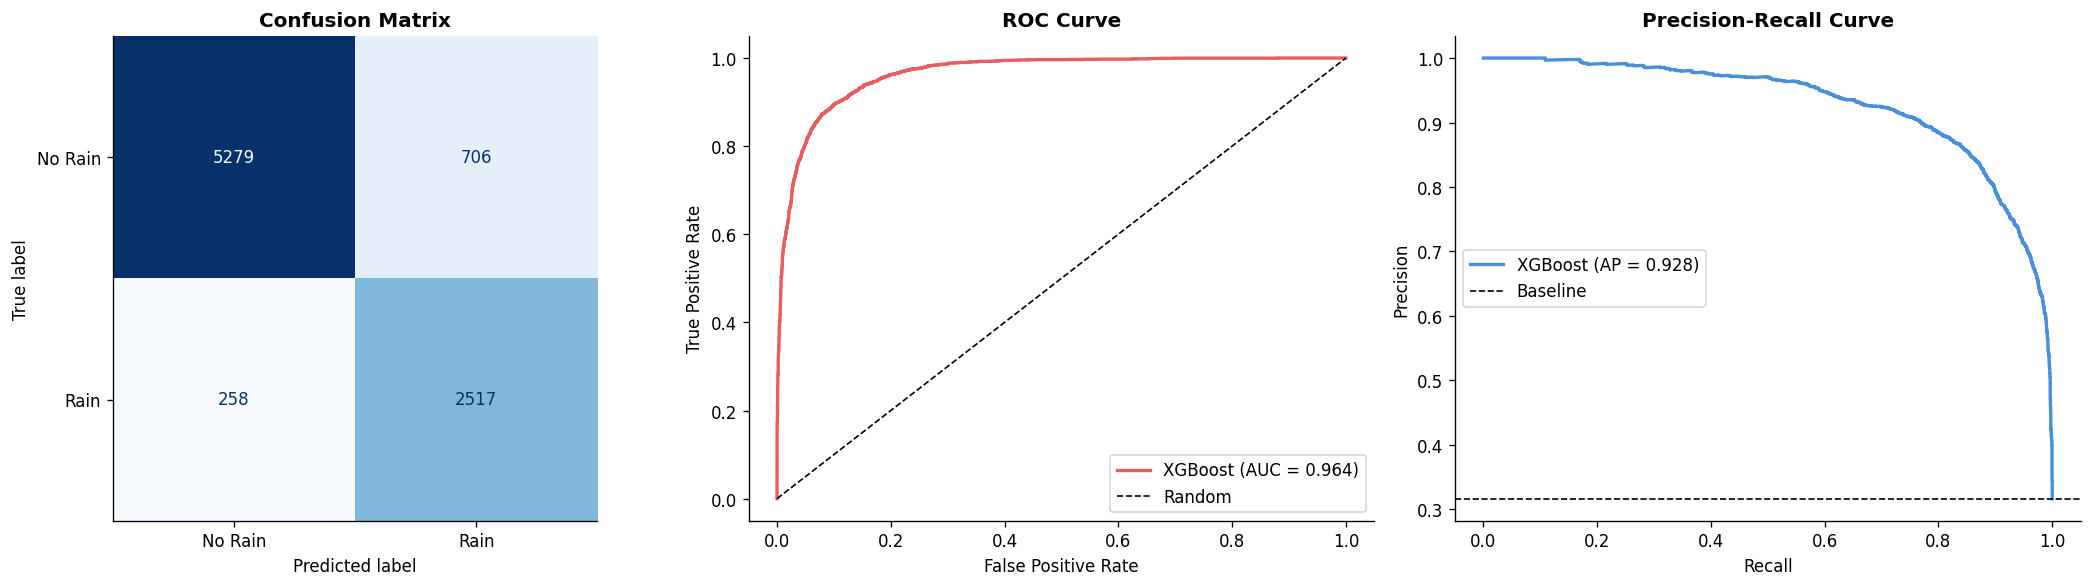

In [25]:
# ── Confusion Matrix + ROC + PR curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="#E85D5D", lw=2, label=f"XGBoost (AUC = {auc:.3f})")
axes[1].plot([0,1], [0,1], "k--", lw=1, label="Random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
axes[2].plot(rec, prec, color="#4A90D9", lw=2, label=f"XGBoost (AP = {ap:.3f})")
axes[2].axhline(y_test.mean(), color="k", linestyle="--", lw=1, label="Baseline")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/evaluation_curves.png", bbox_inches="tight")
plt.show()


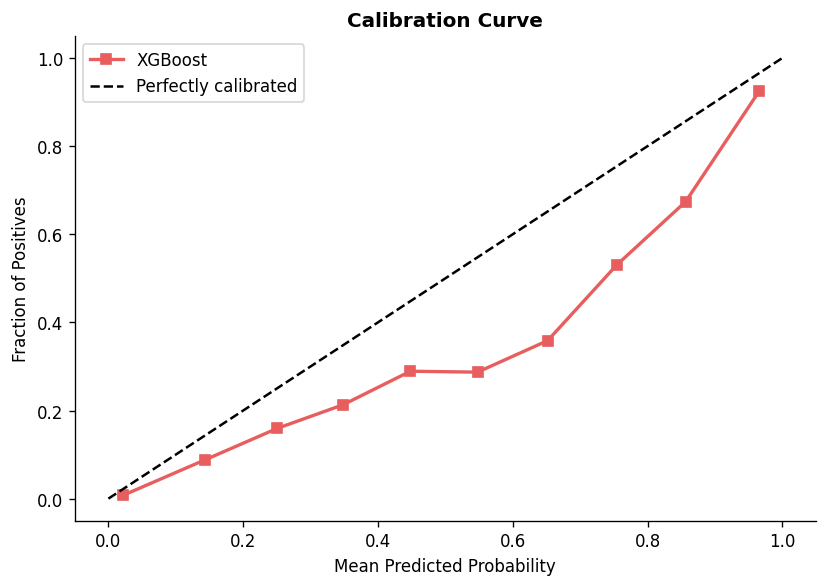

A well-calibrated model follows the diagonal line closely.


In [26]:
# ── Calibration curve (is the model's probability reliable?) ──
fig, ax = plt.subplots(figsize=(7, 5))
frac_pos, mean_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
ax.plot(mean_pred, frac_pos, "s-", color="#E85D5D", label="XGBoost", lw=2)
ax.plot([0,1], [0,1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/calibration_curve.png", bbox_inches="tight")
plt.show()
print("A well-calibrated model follows the diagonal line closely.")


## 6. Feature Importance

In [27]:
importance_gain   = model.get_booster().get_score(importance_type="gain")
importance_weight = model.get_booster().get_score(importance_type="weight")
importance_cover  = model.get_booster().get_score(importance_type="cover")

imp_df = pd.DataFrame({
    "Feature": FEATURES,
    "Gain"   : [importance_gain.get(f, 0)   for f in FEATURES],
    "Weight" : [importance_weight.get(f, 0) for f in FEATURES],
    "Cover"  : [importance_cover.get(f, 0)  for f in FEATURES],
}).sort_values("Gain", ascending=False).reset_index(drop=True)

print("── Feature Importance (by Gain) ──")
imp_df


── Feature Importance (by Gain) ──


,Feature,Gain,Weight,Cover
0,precipitation,353.595123,325.0,1100.990723
1,high_cloud_cover,203.817551,279.0,1009.589600
2,medium_cloud_cover,113.058388,375.0,789.572998
3,total_cloud_cover,41.835270,278.0,542.953369
4,humidity,28.830601,661.0,592.250305
5,low_cloud_cover,28.803560,207.0,304.118011
6,surface_pressure,18.997618,727.0,504.012695
7,month,16.706511,547.0,472.348541
8,wind_speed,12.185110,594.0,270.249329
9,temp_lag_1,11.105606,215.0,501.754578


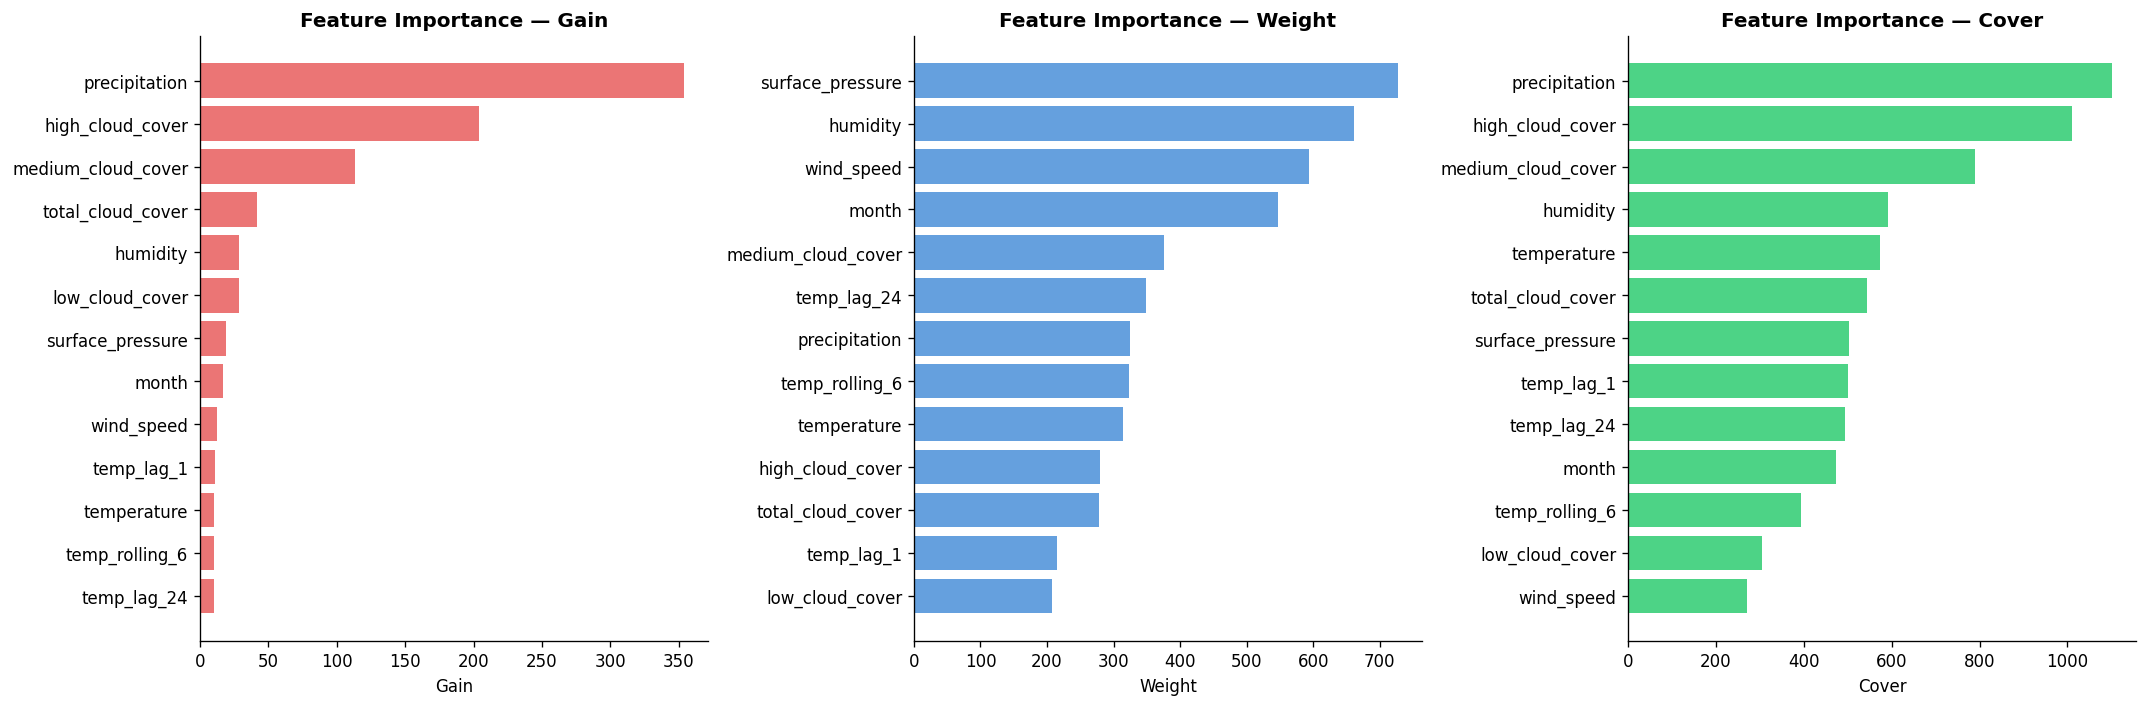

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ["Gain", "Weight", "Cover"]
colors  = ["#E85D5D", "#4A90D9", "#2ECC71"]

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = imp_df.sort_values(metric, ascending=True)
    ax.barh(sorted_df["Feature"], sorted_df[metric], color=color, alpha=0.85)
    ax.set_title(f"Feature Importance — {metric}", fontweight="bold")
    ax.set_xlabel(metric)

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/feature_importance.png", bbox_inches="tight")
plt.show()


## 7. Threshold Tuning
Default threshold is 0.5, but tuning it can improve F1 for imbalanced classes.

In [29]:
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for thr in thresholds:
    yp = (y_pred_prob >= thr).astype(int)
    results.append({
        "threshold": round(thr, 2),
        "accuracy" : accuracy_score(y_test, yp),
        "f1"       : f1_score(y_test, yp, zero_division=0),
        "precision": confusion_matrix(y_test, yp)[1,1] /
                     (confusion_matrix(y_test, yp)[1,1] + confusion_matrix(y_test, yp)[0,1] + 1e-9),
        "recall"   : confusion_matrix(y_test, yp)[1,1] /
                     (confusion_matrix(y_test, yp)[1,1] + confusion_matrix(y_test, yp)[1,0] + 1e-9),
    })

thr_df = pd.DataFrame(results)
best_thr = thr_df.loc[thr_df["f1"].idxmax(), "threshold"]
print(f"Best threshold by F1 : {best_thr}")
print(thr_df.to_string(index=False))


Best threshold by F1 : 0.7
 threshold  accuracy       f1  precision   recall
      0.10  0.789269 0.748158   0.601976 0.988108
      0.15  0.817694 0.772734   0.638523 0.978378
      0.20  0.835959 0.789697   0.664860 0.972252
      0.25  0.847146 0.799880   0.683350 0.964324
      0.30  0.858904 0.810951   0.704491 0.955315
      0.35  0.869178 0.820376   0.725936 0.943063
      0.40  0.877968 0.828878   0.745680 0.932973
      0.45  0.884589 0.834561   0.764388 0.918919
      0.50  0.889954 0.839280   0.780949 0.907027
      0.55  0.896689 0.846271   0.800450 0.897658
      0.60  0.900114 0.848851   0.815196 0.885405
      0.65  0.903539 0.851832   0.829577 0.875315
      0.70  0.906050 0.853167   0.844876 0.861622
      0.75  0.907306 0.851879   0.862579 0.841441
      0.80  0.904110 0.842283   0.879263 0.808288
      0.85  0.899772 0.829448   0.899705 0.769369
      0.90  0.885731 0.794160   0.924808 0.695856


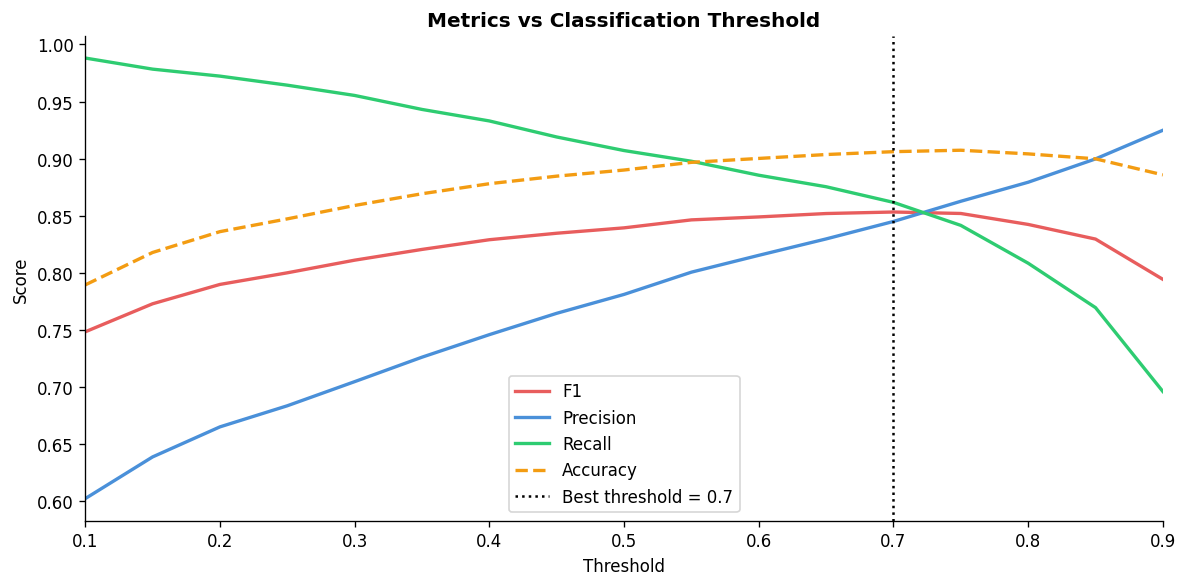


✅ Using threshold: 0.7


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_df["threshold"], thr_df["f1"],        label="F1",        lw=2, color="#E85D5D")
ax.plot(thr_df["threshold"], thr_df["precision"],  label="Precision",  lw=2, color="#4A90D9")
ax.plot(thr_df["threshold"], thr_df["recall"],     label="Recall",     lw=2, color="#2ECC71")
ax.plot(thr_df["threshold"], thr_df["accuracy"],   label="Accuracy",   lw=2, color="#F39C12", linestyle="--")
ax.axvline(best_thr, color="black", linestyle=":", label=f"Best threshold = {best_thr}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs Classification Threshold", fontweight="bold")
ax.legend(); ax.set_xlim(0.1, 0.9)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/threshold_tuning.png", bbox_inches="tight")
plt.show()

BEST_THRESHOLD = float(best_thr)
print(f"\n✅ Using threshold: {BEST_THRESHOLD}")


## 8. Save Model & Artifacts

In [18]:
# Save XGBoost model
model_path = os.path.join(MODEL_DIR, "rain_model.json")
model.save_model(model_path)
print(f"✅ Model saved       → {model_path}")

# Save metadata
y_pred_tuned = (y_pred_prob >= BEST_THRESHOLD).astype(int)

meta = {
    "model"            : "XGBoostClassifier",
    "features"         : FEATURES,
    "target"           : TARGET,
    "best_threshold"   : BEST_THRESHOLD,
    "train_rows"       : int(len(X_train)),
    "test_rows"        : int(len(X_test)),
    "metrics": {
        "accuracy"     : round(accuracy_score(y_test, y_pred_tuned), 4),
        "f1_score"     : round(f1_score(y_test, y_pred_tuned, zero_division=0), 4),
        "roc_auc"      : round(roc_auc_score(y_test, y_pred_prob), 4),
        "avg_precision": round(average_precision_score(y_test, y_pred_prob), 4),
    },
    "cv_mean_roc_auc"  : round(float(np.mean(cv_scores["roc_auc"])), 4),
    "cv_std_roc_auc"   : round(float(np.std(cv_scores["roc_auc"])), 4),
    "feature_importance_gain": {
        k: round(v, 4) for k, v in
        sorted(importance_gain.items(), key=lambda x: x[1], reverse=True)
    }
}

meta_path = os.path.join(MODEL_DIR, "model_meta.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"✅ Metadata saved    → {meta_path}")
print(f"\nFinal Metrics (threshold={BEST_THRESHOLD}):")
for k, v in meta["metrics"].items():
    print(f"  {k:<18}: {v}")


✅ Model saved       → ../models/xgboost\rain_model.json
✅ Metadata saved    → ../models/xgboost\model_meta.json

Final Metrics (threshold=0.2):
  accuracy          : 0.8919
  f1_score          : 0.5239
  roc_auc           : 0.8873
  avg_precision     : 0.4902


## 9. Inference Function
This is what `app/services/predictor.py` will import and use.

In [19]:
def predict_rain(input_dict: dict, threshold: float = BEST_THRESHOLD) -> dict:
    """
    Predict whether it will rain tomorrow given current weather readings.

    Args:
        input_dict : dict with keys matching FEATURES list
        threshold  : classification threshold (default = tuned best threshold)

    Returns:
        dict with rain_tomorrow (bool), probability (float), confidence (str)

    Example:
        predict_rain({
            "temperature"       : 22.5,
            "surface_pressure"  : 1008.0,
            "total_cloud_cover" : 0.6,
            "low_cloud_cover"   : 0.3,
            "medium_cloud_cover": 0.2,
            "high_cloud_cover"  : 0.1,
            "precipitation"     : 0.0,
            "wind_speed"        : 4.5,
            "temp_rolling_6"    : 21.8,
            "temp_lag_1"        : 21.2,
            "temp_lag_24"       : 20.5,
            "month"             : 6,
        })
    """
    row  = pd.DataFrame([{feat: input_dict[feat] for feat in FEATURES}])
    prob = model.predict_proba(row)[0][1]
    will_rain = prob >= threshold

    if prob > 0.75:   confidence = "high (rain likely)"
    elif prob > 0.55: confidence = "medium"
    elif prob < 0.25: confidence = "high (no rain likely)"
    else:             confidence = "low (uncertain)"

    return {
        "rain_tomorrow": bool(will_rain),
        "probability"  : round(float(prob), 4),
        "confidence"   : confidence,
        "threshold_used": threshold,
    }


# ── Demo on 5 test samples ──
print("── Demo Predictions on Test Samples ──")
print(f"{'#':<4} {'Prob':>6} {'Predicted':>12} {'Actual':>10} {'Match':>6}")
print("─" * 45)
for i in range(5):
    sample = X_test.iloc[i].to_dict()
    result = predict_rain(sample)
    actual = int(y_test.iloc[i])
    pred   = "Rain" if result["rain_tomorrow"] else "No Rain"
    act    = "Rain" if actual else "No Rain"
    match  = "✅" if pred == act else "❌"
    print(f"{i+1:<4} {result['probability']:>6.4f} {pred:>12} {act:>10} {match:>6}")


── Demo Predictions on Test Samples ──
#      Prob    Predicted     Actual  Match
─────────────────────────────────────────────
1    0.0447      No Rain    No Rain      ✅
2    0.0716      No Rain    No Rain      ✅
3    0.0498      No Rain    No Rain      ✅
4    0.1446      No Rain       Rain      ❌
5    0.1354      No Rain    No Rain      ✅


In [37]:
# ── Final summary ──
print("\n" + "═"*50)
print("  TRAINING COMPLETE — SUMMARY")
print("═"*50)
print(f"  Dataset    : {len(df):,} hourly records (1 year)")
print(f"  Train/Test : {len(X_train):,} / {len(X_test):,} rows")
print(f"  CV ROC-AUC : {np.mean(cv_scores['roc_auc']):.4f} ± {np.std(cv_scores['roc_auc']):.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"  Best Threshold: {BEST_THRESHOLD}")
print(f"  Model saved → {model_path}")
print("═"*50)



══════════════════════════════════════════════════
  TRAINING COMPLETE — SUMMARY
══════════════════════════════════════════════════
  Dataset    : 8,736 hourly records (1 year)
  Train/Test : 6,988 / 1,748 rows
  CV ROC-AUC : 0.7316 ± 0.1141
  Test ROC-AUC: 0.8875
  Best Threshold: 0.2
  Model saved → ../models/xgboost\rain_model.json
══════════════════════════════════════════════════
